In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

# ALL TABLES (Data Cleaning)

## Order Table

In [3]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [6]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [7]:
orders[(orders['order_status'] == 'canceled') | (orders['order_status'] == 'unavailable') ]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14
586,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22
687,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05
...,...,...,...,...,...,...,...,...
99252,aaab15da689073f8f9aa978a390a69d1,df20748206e4b865b2f14a5eabbfcf34,unavailable,2018-01-16 14:27:59,2018-01-17 03:37:34,NaT,NaT,2018-02-06
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [8]:
delivered_missing = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isna())
]
orders = orders.drop(delivered_missing.index)

In [9]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [10]:
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

In [11]:
carrier_diff = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.days
carrier_mean = carrier_diff.mean()

orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].fillna
(orders['order_approved_at'] + pd.to_timedelta(round(carrier_mean), unit='D'))


0       2017-10-04 11:07:15
1       2018-07-28 03:24:27
2       2018-08-10 08:55:23
3       2017-11-20 19:45:59
4       2018-02-15 22:20:29
                ...        
99436   2017-03-11 09:54:05
99437   2018-02-08 13:10:37
99438   2017-08-29 15:04:16
99439   2018-01-10 21:36:21
99440   2018-03-11 11:20:28
Name: order_approved_at, Length: 99433, dtype: datetime64[ns]

In [12]:
customers_Diff = (orders['order_delivered_customer_date'] - orders['order_approved_at']).dt.days
customers_mean = customers_Diff.mean()

orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(
    orders['order_approved_at'] + pd.to_timedelta( round(customers_mean) , unit='D')
)

In [13]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [14]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_delay'] =(orders['order_delivered_customer_date']-orders['order_estimated_delivery_date']).dt.days

orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year 

In [15]:
orders.duplicated().sum()

np.int64(0)

In [16]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99433 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99433 non-null  object        
 1   customer_id                    99433 non-null  object        
 2   order_status                   99433 non-null  object        
 3   order_purchase_timestamp       99433 non-null  datetime64[ns]
 4   order_approved_at              99433 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99433 non-null  object        
 6   order_delivered_customer_date  99433 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99433 non-null  datetime64[ns]
 8   delivery_days                  99433 non-null  int64         
 9   delivery_delay                 99433 non-null  int64         
 10  purchase_month                 99433 non-null  int32         
 11  purchase_year       

In [17]:
orders.reset_index(drop=True , inplace=True)

In [18]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99433 entries, 0 to 99432
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99433 non-null  object        
 1   customer_id                    99433 non-null  object        
 2   order_status                   99433 non-null  object        
 3   order_purchase_timestamp       99433 non-null  datetime64[ns]
 4   order_approved_at              99433 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99433 non-null  object        
 6   order_delivered_customer_date  99433 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99433 non-null  datetime64[ns]
 8   delivery_days                  99433 non-null  int64         
 9   delivery_delay                 99433 non-null  int64         
 10  purchase_month                 99433 non-null  int32         
 11  purchase_year  

In [19]:
# orders.to_csv('Orders.csv' , index=False)

## order items Table

In [20]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [21]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [22]:
order_items['order_item_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21])

In [23]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [24]:
order_items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

In [25]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [26]:
order_items.duplicated().sum()

np.int64(0)

In [27]:
# order_items.to_csv('Order_items.csv' , index=False)

## Product Table

In [28]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [29]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [30]:
products.duplicated().sum()

np.int64(0)

In [31]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [32]:
products['product_category_name'].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio', nan,
       'moveis_sala', 'sinalizacao_e_seguranca', 'climatizacao',
       'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefonia_fixa',
   

In [33]:
products['product_category_name'].nunique()

73

In [34]:
products['product_category_name'].fillna(products['product_category_name'].mode()[0] ,inplace=True)

C:\Users\Tesla\AppData\Local\Temp\ipykernel_12528\3354229172.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna(products['product_category_name'].mode()[0] ,inplace=True)


In [35]:
products['product_name_lenght'] = products.groupby('product_category_name')['product_name_lenght'].transform(
    lambda x:x.fillna(x.mode()[0]))
products['product_description_lenght'] = products.groupby('product_category_name')['product_description_lenght'].transform(
    lambda x:x.fillna(x.mode()[0]))
products['product_photos_qty'] = products.groupby('product_category_name')['product_photos_qty'].transform(
    lambda x: x.fillna(x.median()))


In [36]:
products['product_length_cm'] = products.groupby('product_category_name')['product_length_cm'].transform(
    lambda x:x.fillna(x.median()))
products['product_weight_g'] = products.groupby('product_category_name')['product_weight_g'].transform(
    lambda x:x.fillna(x.median()))
products['product_height_cm'] = products.groupby('product_category_name')['product_height_cm'].transform(
    lambda x:x.fillna(x.median()))
products['product_width_cm'] = products.groupby('product_category_name')['product_width_cm'].transform(
    lambda x:x.fillna(x.median()))

In [37]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [38]:
# products.to_csv('Products.csv' , index=False)

## customer Table 

In [39]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [40]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [41]:
customers.duplicated().sum()

np.int64(0)

In [42]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [43]:
# customers.to_csv('Customers.csv' , index=False)

## review Table

In [44]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [45]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [46]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

In [47]:
reviews.dtypes

review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

In [48]:
reviews['review_comment_title'].fillna('No Title' , inplace=True)
reviews['review_comment_message'].fillna('No Comment', inplace=True)

C:\Users\Tesla\AppData\Local\Temp\ipykernel_12528\374399333.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews['review_comment_title'].fillna('No Title' , inplace=True)
C:\Users\Tesla\AppData\Local\Temp\ipykernel_12528\374399333.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [49]:
reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [50]:
reviews.duplicated().sum()

np.int64(0)

In [51]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [52]:
# reviews.to_csv('reviews.csv' , index=False)

## payment Table

In [53]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [54]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [55]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [56]:
payments.duplicated().sum()

np.int64(0)

In [57]:
# payments.to_csv('payments.csv' , index=False)

## seller Table

In [58]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [59]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [60]:
sellers.duplicated().sum()

np.int64(0)

In [61]:
# sellers.to_csv('sellers.csv',index=False)

## category Table

In [62]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [63]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [64]:
category.duplicated().sum()

np.int64(0)

In [65]:
# category.to_csv('category.csv',index=False)

## geolocation Table

In [66]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [67]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [68]:
geolocation.duplicated().sum()

np.int64(261831)

In [69]:
geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix'] , keep='first' ,inplace=True)

In [70]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19015 entries, 0 to 999846
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  object 
 4   geolocation_state            19015 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 891.3+ KB


In [71]:
geolocation.reset_index(drop=True , inplace=True)

In [72]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  object 
 4   geolocation_state            19015 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 742.9+ KB


In [73]:
# geolocation.to_csv('geolocation.csv',index=False)

# DataAnalysis

## Order

In [74]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99433 entries, 0 to 99432
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99433 non-null  object        
 1   customer_id                    99433 non-null  object        
 2   order_status                   99433 non-null  object        
 3   order_purchase_timestamp       99433 non-null  datetime64[ns]
 4   order_approved_at              99433 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99433 non-null  object        
 6   order_delivered_customer_date  99433 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99433 non-null  datetime64[ns]
 8   delivery_days                  99433 non-null  int64         
 9   delivery_delay                 99433 non-null  int64         
 10  purchase_month                 99433 non-null  int32         
 11  purchase_year  

In [75]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,<bound method NDFrame.fillna of 0 2017-1...,2018-08-07 15:27:45,2018-08-13,13,-6,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,<bound method NDFrame.fillna of 0 2017-1...,2018-08-17 18:06:29,2018-09-04,9,-18,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,<bound method NDFrame.fillna of 0 2017-1...,2017-12-02 00:28:42,2017-12-15,13,-13,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,<bound method NDFrame.fillna of 0 2017-1...,2018-02-16 18:17:02,2018-02-26,2,-10,2,2018


In [76]:
orders['order_status'].value_counts().reset_index()

,order_status,count
0,delivered,96470
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


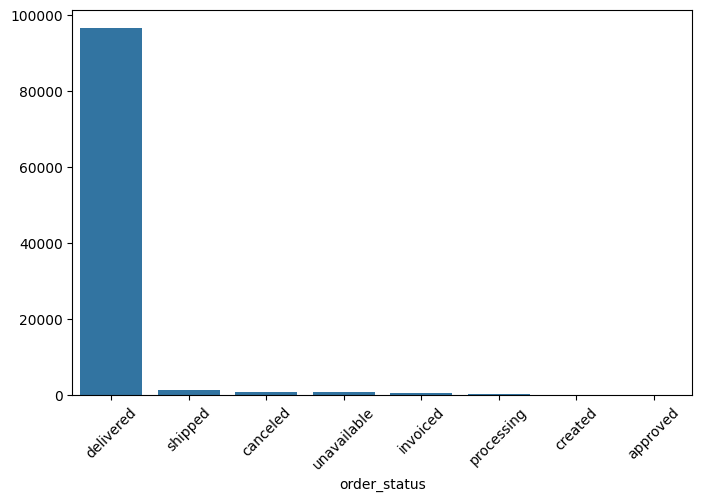

In [77]:
plt.figure(figsize=(8,5))
sns.barplot(x =orders['order_status'].value_counts().index , y=orders['order_status'].value_counts().values)
plt.xticks(rotation=45)
plt.show()

In [78]:
orders['delivery_delay'].describe()

count    99433.000000
mean       -11.901129
std         10.218684
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

In [79]:
early_deliveries = (orders['delivery_delay'] < 0).mean() * 100
late_deliveries = (orders['delivery_delay']  > 0).mean() * 100 

print(f"mean_early_deliveries ={early_deliveries} %\nmean_late_deliveries ={late_deliveries} % ")

mean_early_deliveries =91.86286242997798 %
mean_late_deliveries =6.781450826184465 % 


In [80]:
Q3 = orders['delivery_delay'].quantile(0.75)
Q1 = orders['delivery_delay'].quantile(0.25)
IQR = Q3 - Q1 
UB = Q3 + 1.5 * IQR
LB = Q1 - 1.5 * IQR

outliers = orders[(orders['delivery_delay'] < LB) | (orders['delivery_delay'] > UB)]
outliers

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,<bound method NDFrame.fillna of 0 2017-1...,2017-10-09 22:23:46,2017-09-28,21,11,9,2017
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,<bound method NDFrame.fillna of 0 2017-1...,2018-03-21 22:03:54,2018-03-12,28,9,2,2018
97,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,delivered,2017-11-22 11:32:22,2017-11-22 11:46:50,<bound method NDFrame.fillna of 0 2017-1...,2017-12-28 19:43:00,2017-12-11,36,17,11,2017
99,23f553848a03aaab35bb3f9f87725125,c622b892a190735ef81c0087973fa16d,delivered,2018-06-05 09:10:34,2018-06-05 09:32:22,<bound method NDFrame.fillna of 0 2017-1...,2018-06-18 12:36:54,2018-07-23,13,-35,6,2018
110,9d531c565e28c3e0d756192f84d8731f,d4faa220408c20e53595d2950f361f3b,delivered,2017-11-28 21:00:44,2017-12-01 09:31:15,<bound method NDFrame.fillna of 0 2017-1...,2018-01-23 21:38:52,2017-12-22,56,32,11,2017
...,...,...,...,...,...,...,...,...,...,...,...,...
99304,f930a1f6247ed00d6fa9d8a09782c7b4,4ab4db2f93c68d5914dc5eb566dc486c,delivered,2018-06-05 12:28:11,2018-06-05 14:31:34,<bound method NDFrame.fillna of 0 2017-1...,2018-06-07 17:28:31,2018-07-11,2,-34,6,2018
99408,c627fe35fce1a754bc5b812d0b8ff379,42b0671b440d1f2527bddd8b723e0a0c,delivered,2018-06-03 18:44:31,2018-06-03 18:55:15,<bound method NDFrame.fillna of 0 2017-1...,2018-06-07 13:22:19,2018-07-11,3,-34,6,2018
99409,e6cc57f923c4dab2222b8c9aa8742eea,2f4a42f9bb4b9a8cd402fa549df5c7fd,delivered,2018-02-07 12:09:45,2018-02-07 12:31:13,<bound method NDFrame.fillna of 0 2017-1...,2018-03-05 18:56:39,2018-05-11,26,-67,2,2018
99415,38e9133ce29f6bbe35aed9c3863dce01,ad312389a098ceff46ce92c4595c06d0,delivered,2017-10-12 20:54:11,2017-10-14 03:28:24,<bound method NDFrame.fillna of 0 2017-1...,2017-11-21 17:06:59,2017-10-31,39,21,10,2017


<Axes: >

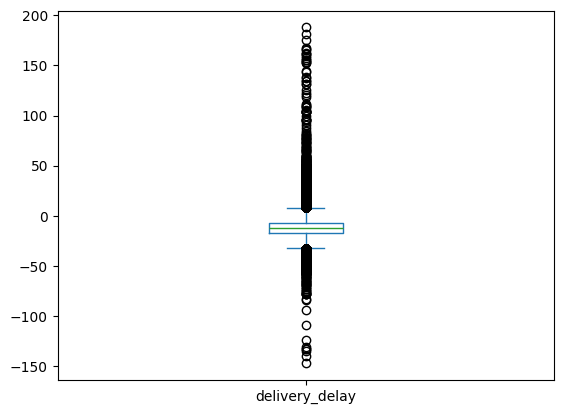

In [81]:
orders['delivery_delay'].plot(kind='box')

**The company delivers about 12 days earlier than usual.**
**The order delivery rate is approximately 92%, and the delay rate is about 8%.** 
**There are outliers in the data, but I haven't deleted them.**

In [82]:
orders['purchase_Day'] = orders['order_purchase_timestamp'].dt.day_name()

In [83]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year,purchase_Day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,10,2017,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,<bound method NDFrame.fillna of 0 2017-1...,2018-08-07 15:27:45,2018-08-13,13,-6,7,2018,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,<bound method NDFrame.fillna of 0 2017-1...,2018-08-17 18:06:29,2018-09-04,9,-18,8,2018,Wednesday


In [84]:
orders['purchase_Day'].value_counts().reset_index()

,purchase_Day,count
0,Monday,16196
1,Tuesday,15962
2,Wednesday,15550
3,Thursday,14760
4,Friday,14121
5,Sunday,11957
6,Saturday,10887


<Axes: xlabel='purchase_Day'>

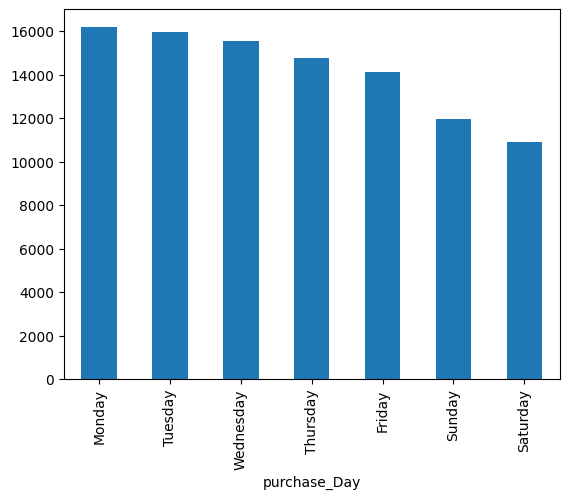

In [85]:
orders['purchase_Day'].value_counts().plot(kind='bar')

In [86]:
orders['purchase_month'].value_counts().reset_index()

,purchase_month,count
0,8,10843
1,5,10572
2,7,10315
3,3,9893
4,6,9409
5,4,9343
6,2,8508
7,1,8069
8,11,7543
9,12,5674


**The number of orders on Mondays is approximately 16,196 per week. Therefore, at the beginning of each week, there is a large workforce and sufficient inventory.**
**August is one of the months with the highest demand for advertising before August, May, and July.**

In [87]:
orders['Transaction'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.days

In [88]:
orders['Transaction'].describe()

count    99433.000000
mean         0.269387
std          0.985504
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        187.000000
Name: Transaction, dtype: float64

In [89]:
orders.groupby('order_status')['Transaction'].median().reset_index()

,order_status,Transaction
0,approved,2.5
1,canceled,0.0
2,created,0.0
3,delivered,0.0
4,invoiced,0.0
5,processing,0.0
6,shipped,0.0
7,unavailable,0.0


In [90]:
cancel_rate = (orders['order_status'] == 'canceled').mean() * 100
unavailable_rate = (orders['order_status'] == 'unavailable').mean() * 100
cancel_rate, unavailable_rate

(np.float64(0.6285639576398178), np.float64(0.6124727203242385))

In [91]:
orders.groupby('order_status')['delivery_days'].mean().reset_index()

,order_status,delivery_days
0,approved,14.500000
1,canceled,12.430400
2,created,12.000000
3,delivered,12.093604
4,invoiced,12.210191
5,processing,12.551495
6,shipped,12.299910
7,unavailable,12.814450


**For those who cancel their orders, the problem isn't the payment methods, but rather the number of days required for delivery. We might change the shipping company, or the delivery person might be late in forwarding the order to the shipping company.**

In [92]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year,purchase_Day,Transaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,10,2017,Monday,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,<bound method NDFrame.fillna of 0 2017-1...,2018-08-07 15:27:45,2018-08-13,13,-6,7,2018,Tuesday,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,<bound method NDFrame.fillna of 0 2017-1...,2018-08-17 18:06:29,2018-09-04,9,-18,8,2018,Wednesday,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,<bound method NDFrame.fillna of 0 2017-1...,2017-12-02 00:28:42,2017-12-15,13,-13,11,2017,Saturday,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,<bound method NDFrame.fillna of 0 2017-1...,2018-02-16 18:17:02,2018-02-26,2,-10,2,2018,Tuesday,0


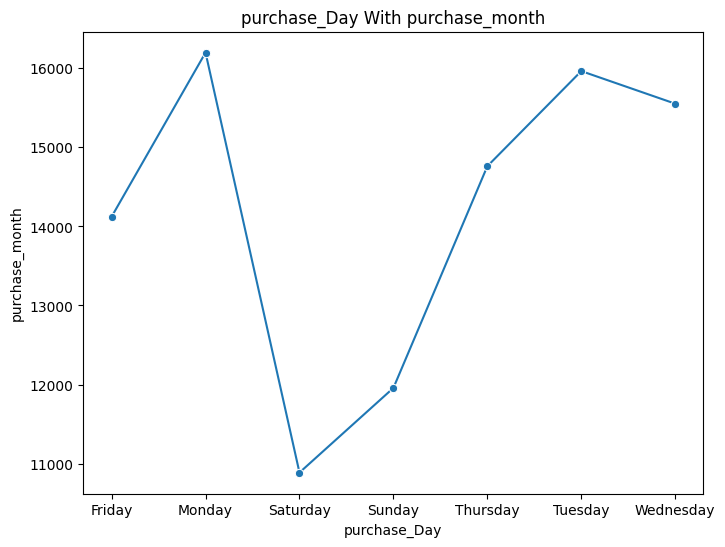

In [ ]:
purchase_Day_Month = orders.groupby('purchase_Day')["purchase_month"].count().reset_index()

plt.figure(figsize=(8,6))
sns.lineplot(data=purchase_Day_Month , x="purchase_Day" , y="purchase_month",marker='o')
plt.title("purchase_Day With purchase_month")
plt.show()

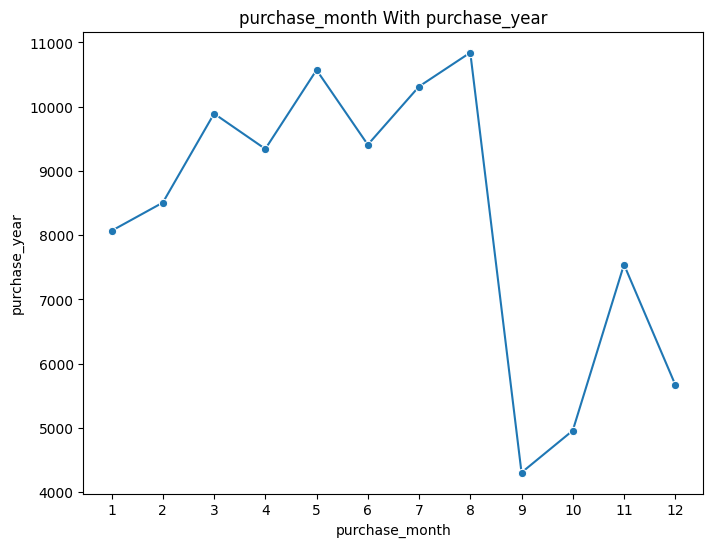

In [94]:
purchase_Month_year = orders.groupby("purchase_month")["purchase_year"].count().reset_index()

plt.figure(figsize=(8,6))
sns.lineplot(data=purchase_Month_year , x="purchase_month" , y="purchase_year",marker='o')
plt.title("purchase_month With purchase_year")
plt.xticks(range(1,13))
plt.show()

## Order Items

In [95]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [96]:
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [97]:
order_items['price'].median()

np.float64(74.99)

In [98]:
order_items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [99]:
order_items['freight_value'].median()

np.float64(16.26)

In [100]:
order_items['seller_id'].value_counts().head(20)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
4869f7a5dfa277a7dca6462dcf3b52b2    1156
3d871de0142ce09b7081e2b9d1733cb1    1147
8b321bb669392f5163d04c59e235e066    1018
cca3071e3e9bb7d12640c9fbe2301306     830
620c87c171fb2a6dd6e8bb4dec959fc6     798
a1043bafd471dff536d0c462352beb48     770
e9779976487b77c6d4ac45f75ec7afe9     750
f8db351d8c4c4c22c6835c19a46f01b0     724
d2374cbcbb3ca4ab1086534108cc3ab7     631
391fc6631aebcf3004804e51b40bcf1e     613
Name: count, dtype: int64

In [101]:
order_items.groupby('seller_id')['price'].median().head(20).sort_values(ascending=False).reset_index()

,seller_id,price
0,0015a82c2db000af6aaaf3ae2ecb0532,895.00
1,010543a62bd80aa422851e79a3bc7540,708.00
2,014c0679dd340a0e338872e7ec85666a,400.00
3,001e6ad469a905060d959994f1b41e4f,250.00
4,010da0602d7774602cd1b3f5fb7b709e,169.90
5,01bcc9d254a0143f0ce9791b960b2a47,128.00
6,003554e2dce176b5555353e4f3555ac8,120.00
7,0176f73cc1195f367f7b32db1e5b3aa8,119.90
8,00ee68308b45bc5e2660cd833c3f81cc,110.00
9,004c9cd9d87a3c30c522c48c4fc07416,109.99


In [102]:
order_items.groupby('product_id')['price'].median().head(20).sort_values(ascending=False).reset_index()

,product_id,price
0,00126f27c813603687e6ce486d909d01,249.00
1,0009406fd7479715e4bef61dd91f2462,229.00
2,002159fe700ed3521f46cfcf6e941c76,199.70
3,000d9be29b5207b54e86aa1b1ac54872,199.00
4,00088930e925c41fd95ebfe695fd2655,129.90
5,002959d7a0b0990fe2d69988affcbc80,129.90
6,002552c0663708129c0019cc97552d7d,108.00
7,00066f42aeeb9f3007548bb9d3f33c38,101.65
8,00250175f79f584c14ab5cecd80553cd,79.99
9,001c5d71ac6ad696d22315953758fa04,79.90


In [103]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [104]:
order_items.groupby('seller_id')['order_item_id'].count().head(20).sort_values(ascending=False).reset_index()

,seller_id,order_item_id
0,001cca7ae9ae17fb1caed9dfb1094831,239
1,00ee68308b45bc5e2660cd833c3f81cc,172
2,004c9cd9d87a3c30c522c48c4fc07416,170
3,00fc707aaaad2d31347cf883cd2dfe10,135
4,002100f778ceb8431b7a1020ff7ab48f,55
5,0176f73cc1195f367f7b32db1e5b3aa8,39
6,013900e863eace745d3ec7614cab5b1a,26
7,00720abe85ba0859807595bbf045a33b,26
8,014c0679dd340a0e338872e7ec85666a,15
9,014d9a685fd57276679edd00e07089e5,12


In [105]:
order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [106]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year,purchase_Day,Transaction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,10,2017,Monday,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,<bound method NDFrame.fillna of 0 2017-1...,2018-08-07 15:27:45,2018-08-13,13,-6,7,2018,Tuesday,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,<bound method NDFrame.fillna of 0 2017-1...,2018-08-17 18:06:29,2018-09-04,9,-18,8,2018,Wednesday,0


In [107]:
merged = order_items.merge(orders[['order_id', 'order_delivered_customer_date']], on='order_id', how='left')

In [108]:
merged['shipping_delay'] = (merged['order_delivered_customer_date'] - merged['shipping_limit_date']).dt.days

In [109]:
merged['shipping_delay'].describe()

count    112642.000000
mean          5.349284
std          11.197291
min       -1045.000000
25%           0.000000
50%           4.000000
75%           8.000000
max         205.000000
Name: shipping_delay, dtype: float64

In [110]:
late_percentage = (merged['shipping_delay'] > 0).mean() * 100
late_percentage

np.float64(70.26098535286285)

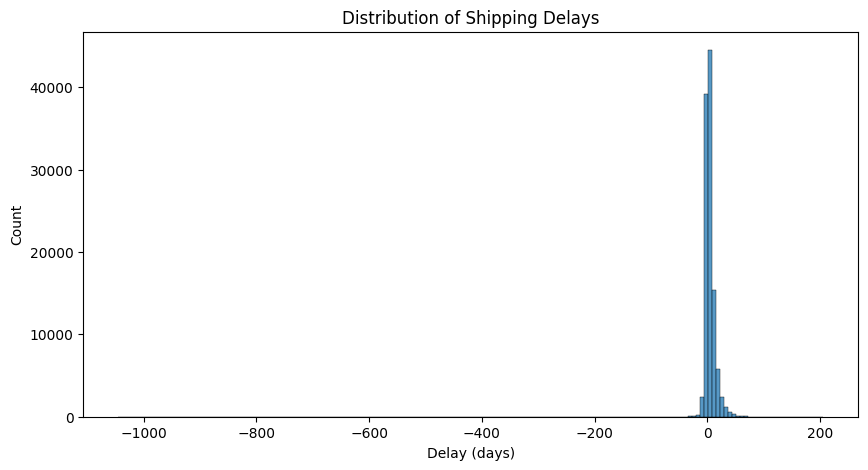

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(merged['shipping_delay'], bins=178)
plt.title("Distribution of Shipping Delays")
plt.xlabel("Delay (days)")
plt.ylabel("Count")
plt.show()


In [112]:
order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [113]:
merged

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_delivered_customer_date,shipping_delay
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-20 23:43:48,1.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-12 16:04:24,9.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-22 13:19:16,3.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-14 13:32:39,-1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-03-01 16:42:31,16.0
...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,2018-05-10 22:56:40,8.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,2018-07-23 20:31:55,3.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,2017-10-28 12:22:22,-3.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,2017-08-16 21:59:40,-5.0


In [114]:
merged.groupby('seller_id')['shipping_delay'].mean().head(20).sort_values(ascending=False).reset_index()

,seller_id,shipping_delay
0,010da0602d7774602cd1b3f5fb7b709e,17.000000
1,014c0679dd340a0e338872e7ec85666a,11.200000
2,011b0eaba87386a2ae96a7d32bb531d1,9.000000
3,002100f778ceb8431b7a1020ff7ab48f,8.818182
4,0176f73cc1195f367f7b32db1e5b3aa8,8.025641
5,004c9cd9d87a3c30c522c48c4fc07416,6.794118
6,001cca7ae9ae17fb1caed9dfb1094831,6.481172
7,01bcc9d254a0143f0ce9791b960b2a47,6.454545
8,001e6ad469a905060d959994f1b41e4f,6.000000
9,013900e863eace745d3ec7614cab5b1a,5.384615


**My 20 worst sellers**

In [115]:
merged.groupby('seller_id')['shipping_delay'].mean().tail(20).sort_values(ascending=False).reset_index()

,seller_id,shipping_delay
0,ffeee66ac5d5a62fe688b9d26f83f534,11.500000
1,fffd5413c0700ac820c7069d66d98c89,7.442623
2,ffcfefa19b08742c5d315f2791395ee5,7.000000
3,ffa6adafb71b807dc13159e26431354c,4.944444
4,ff4ea69c2a729e83e63c7579e4ef8170,4.777778
5,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,4.700000
6,ffc470761de7d0232558ba5e786e57b7,4.354839
7,fec8cd45395b3cb0c2b173d7739706a1,4.000000
8,ff063b022a9a0aab91bad2c9088760b7,3.895833
9,ffdd9f82b9a447f6f8d4b91554cc7dd3,3.850000


**My 20 best sellers**

In [116]:
merged.groupby('product_id')['shipping_delay'].mean().head(20).sort_values(ascending=False).reset_index()


,product_id,shipping_delay
0,002d4ea7c04739c130bb74d7e7cd1694,21.000000
1,002159fe700ed3521f46cfcf6e941c76,14.625000
2,00066f42aeeb9f3007548bb9d3f33c38,13.000000
3,002c6dab60557c48cfd6c2222ef7fd76,12.000000
4,002959d7a0b0990fe2d69988affcbc80,12.000000
5,00126f27c813603687e6ce486d909d01,8.000000
6,0009406fd7479715e4bef61dd91f2462,7.000000
7,00088930e925c41fd95ebfe695fd2655,4.000000
8,002af88741ba70c7b5cf4e4a0ad7ef85,4.000000
9,001795ec6f1b187d37335e1c4704762e,4.000000


**Products that take a long time**

## Product

In [117]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [118]:
products['product_category_name'].value_counts().head(10).reset_index()

,product_category_name,count
0,cama_mesa_banho,3639
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
5,automotivo,1900
6,informatica_acessorios,1639
7,brinquedos,1411
8,relogios_presentes,1329
9,telefonia,1134


In [119]:
products['product_name_lenght'].describe()

count    32951.000000
mean        48.597706
std         10.188472
min          5.000000
25%         42.000000
50%         52.000000
75%         57.000000
max         76.000000
Name: product_name_lenght, dtype: float64

In [120]:
products[products['product_name_lenght'] == 48]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
134,51fed4afb1b41d00ad9d25a73b7fbbc7,consoles_games,48.0,303.0,3.0,250.0,21.0,7.0,15.0
169,16b06ede456b922e56fbb4b3818aa875,fashion_bolsas_e_acessorios,48.0,382.0,5.0,200.0,16.0,9.0,11.0
178,828fe032935d7c1901682e5b6cc076c2,perfumaria,48.0,1063.0,2.0,600.0,20.0,20.0,20.0
198,a5bc1334f1762ce0a844f3f694dc08e1,cama_mesa_banho,48.0,645.0,1.0,1200.0,16.0,10.0,16.0
202,47969dd948e918289f809be899ddfb4c,papelaria,48.0,501.0,1.0,258.0,19.0,12.0,19.0
...,...,...,...,...,...,...,...,...,...
32766,01e20e6604216c8adb31d463214ba00c,casa_construcao,48.0,627.0,1.0,300.0,16.0,11.0,16.0
32767,2d0756de18a80990e11ec355070dd85a,esporte_lazer,48.0,1217.0,1.0,9600.0,51.0,28.0,28.0
32790,6c222e25e3d3c28a643590b836585b4e,bebes,48.0,473.0,1.0,2800.0,70.0,20.0,35.0
32871,d7252737cad49d030f9ce83b50249120,malas_acessorios,48.0,883.0,9.0,2350.0,32.0,52.0,19.0


In [121]:
products.groupby('product_category_name')['product_name_lenght'].mean().head(10).sort_values(ascending=False).reset_index()

,product_category_name,product_name_lenght
0,automotivo,52.145263
1,artigos_de_festas,49.192308
2,agro_industria_e_comercio,49.108108
3,artes,47.090909
4,audio,46.551724
5,alimentos,46.304878
6,bebes,46.056583
7,alimentos_bebidas,44.509615
8,artigos_de_natal,44.369231
9,artes_e_artesanato,44.263158


In [122]:
products.groupby('product_category_name')['product_description_lenght'].mean().head(20).sort_values(ascending=False).reset_index()

,product_category_name,product_description_lenght
0,beleza_saude,1136.933715
1,alimentos,1136.512195
2,bebidas,1047.728395
3,alimentos_bebidas,983.134615
4,cine_foto,939.142857
5,climatizacao,902.822581
6,casa_construcao,855.155556
7,bebes,824.261153
8,automotivo,813.741053
9,agro_industria_e_comercio,807.756757


In [123]:
numerical_product = products.select_dtypes(include='number')
corr=numerical_product.corr()

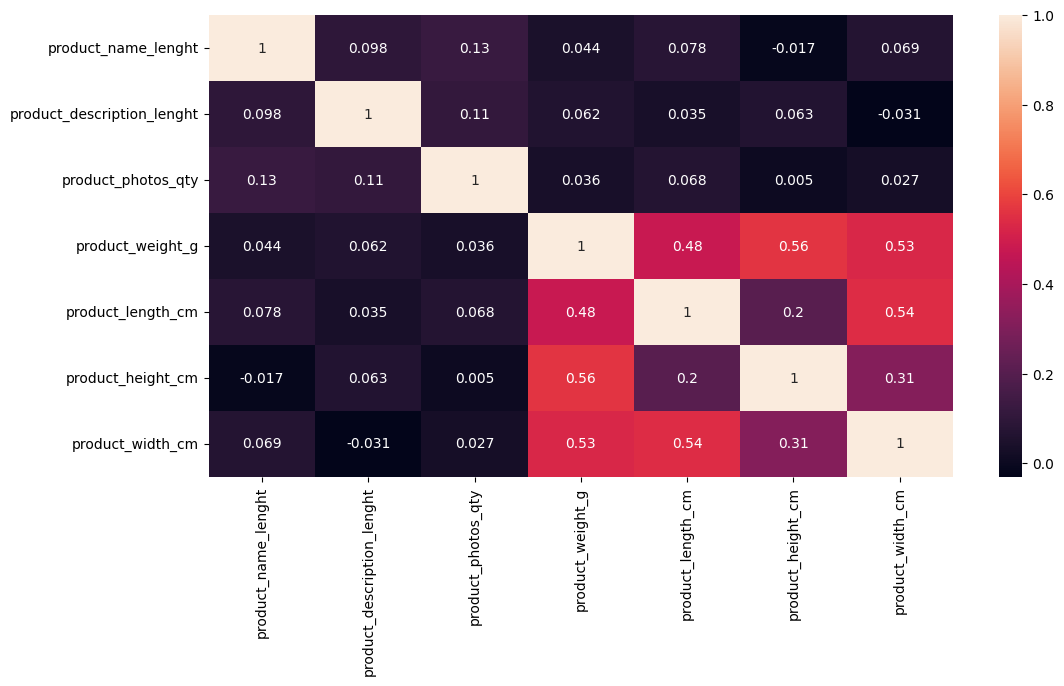

In [124]:
plt.figure(figsize=(12,6))
sns.heatmap(corr,annot=True)
plt.show()

In [125]:
products['product_photos_qty'].describe()

count    32951.000000
mean         2.166975
std          1.728063
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         20.000000
Name: product_photos_qty, dtype: float64

In [126]:
products.groupby('product_category_name')['product_photos_qty'].count().reset_index().head(20).sort_values(by='product_photos_qty',ascending=False)

,product_category_name,product_photos_qty
13,cama_mesa_banho,3639
11,beleza_saude,2444
8,automotivo,1900
12,brinquedos,1411
9,bebes,919
16,casa_construcao,225
19,climatizacao,124
14,casa_conforto,111
2,alimentos_bebidas,104
1,alimentos,82


In [127]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [128]:
products.groupby('product_category_name')['product_weight_g'].max().head(20).sort_values(ascending=False).reset_index()

,product_category_name,product_weight_g
0,cama_mesa_banho,40425.0
1,agro_industria_e_comercio,30000.0
2,bebes,30000.0
3,automotivo,30000.0
4,brinquedos,30000.0
5,casa_construcao,30000.0
6,beleza_saude,30000.0
7,artigos_de_festas,27050.0
8,climatizacao,23300.0
9,casa_conforto,23000.0


## Customer

In [129]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [130]:
customers['customer_city'].nunique()

4119

In [131]:
customers['customer_city'].value_counts().reset_index().head(20)

,customer_city,count
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


In [132]:
customers['customer_state'].value_counts().reset_index().head(20)

,customer_state,count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [133]:
customers.groupby('customer_unique_id')['customer_city'].value_counts().head(10)

customer_unique_id                customer_city
0000366f3b9a7992bf8c76cfdf3221e2  cajamar          1
0000b849f77a49e4a4ce2b2a4ca5be3f  osasco           1
0000f46a3911fa3c0805444483337064  sao jose         1
0000f6ccb0745a6a4b88665a16c9f078  belem            1
0004aac84e0df4da2b147fca70cf8255  sorocaba         1
0004bd2a26a76fe21f786e4fbd80607f  sao paulo        1
00050ab1314c0e55a6ca13cf7181fecf  campinas         1
00053a61a98854899e70ed204dd4bafe  curitiba         1
0005e1862207bf6ccc02e4228effd9a0  teresopolis      1
0005ef4cd20d2893f0d9fbd94d3c0d97  sao luis         1
Name: count, dtype: int64

In [134]:
customers.groupby("customer_zip_code_prefix")["customer_id"].count().sort_values(ascending=False).reset_index().head(20)



,customer_zip_code_prefix,customer_id
0,22790,142
1,24220,124
2,22793,121
3,24230,117
4,22775,110
5,29101,101
6,13212,95
7,35162,93
8,22631,89
9,38400,87


## Review

In [135]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [136]:
reviews['review_score'].value_counts(normalize=True)*100 

review_score
5    57.776344
4    19.291704
1    11.513344
3     8.242965
2     3.175643
Name: proportion, dtype: float64

In [137]:
reviews['review_score'].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

**Customer reviews are very good**

In [138]:
reviews[reviews['review_score'] <=3]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,No Title,No Comment,2018-04-13,2018-04-16 00:39:37
14,9a0abbb668bafb95a6d2b05db43284c4,d7bd0e4afdf94846eb73642b4e3e75c3,3,No Title,No Comment,2017-04-30,2017-05-03 00:02:22
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,No Title,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2018-01-18,2018-01-20 21:25:45
18,fdbdb2629a7cde0f66657acc92084e7f,70a752414a13d09cc1f2b437b914b28e,3,No Title,No Comment,2017-09-29,2017-10-02 01:12:49
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,2018-08-15,2018-08-15 04:10:37
...,...,...,...,...,...,...,...
99203,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,No Title,Tive um problema na entrega em que o correio c...,2018-02-21,2018-02-23 11:43:12
99212,3ea12859f456855149b564d1a221f87a,f62f01ec64c6b221f926ba560907d8f7,3,No Title,No Comment,2017-04-05,2017-04-05 09:42:58
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,No Title,"O produto não foi enviado com NF, não existe v...",2018-05-19,2018-05-20 21:51:06
99216,115d72425fc59eec9a2e9d7594c6d93d,acd45245723df7cb52772a34416b41b1,3,No Title,No Comment,2018-05-08,2018-05-10 14:37:03


In [139]:
reviews[(reviews['review_score'] <=3) & (reviews['review_comment_title']=="No Title") & (reviews['review_comment_message']=="No Comment")]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,No Title,No Comment,2018-04-13,2018-04-16 00:39:37
14,9a0abbb668bafb95a6d2b05db43284c4,d7bd0e4afdf94846eb73642b4e3e75c3,3,No Title,No Comment,2017-04-30,2017-05-03 00:02:22
18,fdbdb2629a7cde0f66657acc92084e7f,70a752414a13d09cc1f2b437b914b28e,3,No Title,No Comment,2017-09-29,2017-10-02 01:12:49
40,ab3056e4fb5a36df4b58c1746e4a6b8f,aad1dcbe4c9fe2e3486e5e04c6649097,2,No Title,No Comment,2018-05-13,2018-05-14 16:29:15
41,eb26c2bfb5030f57dcef30d3f111eb1e,88096595631e8d26b658306256e3ce34,1,No Title,No Comment,2018-02-08,2018-02-10 04:28:43
...,...,...,...,...,...,...,...
99174,cf0b8c06ba024a8a8d3f2ac51fcd99f4,fff2cdc825f9fc0ba3c04227cfa02303,2,No Title,No Comment,2018-03-09,2018-04-23 17:52:49
99184,6cf47345d15e054dd6df872e929bdb27,54e6829fe81bc86cf88b12e6d07ea298,1,No Title,No Comment,2017-06-08,2017-06-08 22:52:39
99198,445a7bd5ce7f7bc9c28a5844c2466acc,2d687102eef8e4949a9d2af49e8fa946,3,No Title,No Comment,2017-12-19,2017-12-28 16:51:12
99212,3ea12859f456855149b564d1a221f87a,f62f01ec64c6b221f926ba560907d8f7,3,No Title,No Comment,2017-04-05,2017-04-05 09:42:58


In [140]:
reviews[reviews['review_score'] <= 3].shape[0] / len(reviews) * 100

22.931951947109567

In [141]:
(reviews['review_score'] == 5).mean() * 100

np.float64(57.776344432798524)

**The number of people dissatisfied with the site is approximately 22,754. When we looked at the problem title and comments, we found about 8,116 people who didn't leave a comment or title to help us understand the problem. We'll focus on 14,638 of them to understand the root cause of the problem.**
**About 22% of our users might leave the site, while about 57% are very satisfied with our platform.**

In [142]:
bad_reviews = reviews[reviews['review_score'] <= 2]
bad_reviews.groupby('order_id')['review_score'].mean().head(20).reset_index().sort_values(by='review_score',ascending=True)

,order_id,review_score
0,0005a1a1728c9d785b8e2b08b904576c,1.0
1,000aed2e25dbad2f9ddb70584c5a2ded,1.0
2,0010dedd556712d7bb69a19cb7bbd37a,1.0
4,00169e31ef4b29deaae414f9a5e95929,1.0
7,001d8f0e34a38c37f7dba2a37d4eba8b,1.0
5,0017afd5076e074a48f1f1a4c7bac9c5,1.0
9,0030d783f979fbc5981e75613b057344,1.0
8,001e7cf2ad6bef3ade12ebc56ceaf0f3,1.0
12,003324c70b19a16798817b2b3640e721,1.0
14,003a94f778ef8cfd50247c8c1b582257,1.0


In [143]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [144]:
reviews['Response_time_days'] = (reviews['review_answer_timestamp'] - reviews['review_creation_date']).dt.days

In [145]:
reviews['Response_time_days'].describe()

count    99224.000000
mean         2.582248
std          9.890526
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        518.000000
Name: Response_time_days, dtype: float64

**What I see is that the customer service is fairly good, not slow, and the response time is good.**

In [146]:
reviews['review_creation_month']=reviews['review_creation_date'].dt.month

In [147]:
reviews.head(2)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,Response_time_days,review_creation_month
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18,2018-01-18 21:46:59,0,1
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10,2018-03-11 03:05:13,1,3


In [148]:
bad_reviews = reviews[reviews['review_score'] <= 2]
bad_reviews.groupby('review_creation_month')['review_score'].mean().sort_values(ascending=False).reset_index()

,review_creation_month,review_score
0,6,1.242353
1,8,1.240867
2,9,1.239923
3,5,1.239745
4,10,1.239016
5,7,1.237811
6,1,1.234672
7,2,1.213262
8,11,1.203540
9,4,1.201523


**June is one of the most stressful and problematic months.**

## Payment

In [149]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [150]:
payments['payment_sequential'].unique()

array([ 1,  2,  4,  5,  3,  8,  6,  7, 10, 11, 17, 19, 27, 12,  9, 15, 13,
       14, 16, 25, 22, 26, 29, 28, 18, 21, 24, 23, 20])

In [151]:
payments['payment_installments'].unique()

array([ 8,  1,  2,  3,  6,  5,  4, 10,  7, 12,  9, 13, 15, 24, 11, 18, 14,
       20, 21, 17, 22,  0, 16, 23])

<Axes: xlabel='payment_type'>

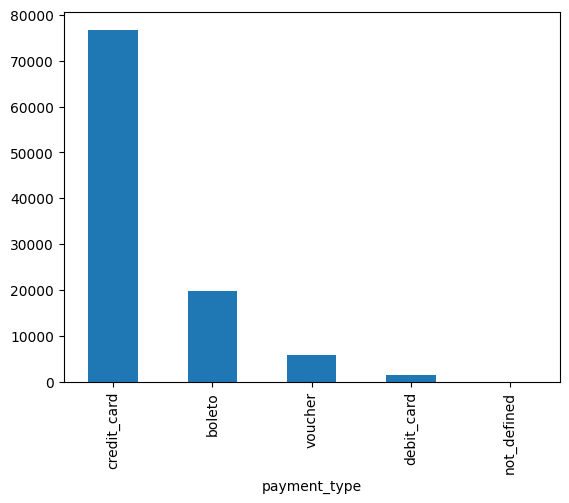

In [152]:
payments['payment_type'].value_counts().plot(kind='bar')

**Most people use a credit card**

In [153]:
payments['payment_installments'].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [154]:
payments.groupby('order_id')['payment_installments'].median().reset_index().sort_values(by='payment_installments',ascending=False).head(20)

,order_id,payment_installments
98884,fe808fc011ee4ae41f2ed8d1d52b6670,24.0
51441,84d2098c97827c6327ed4d7be95e1fc8,24.0
95551,f60ce04ff8060152c83c7c97e246d6a8,24.0
93069,ef71772d55431467890fda2f45c7bdde,24.0
98180,fcbb6af360b31b05460c2c8e524588c0,24.0
84333,d8d5cc8b2d42cce90b7ea35e5691a7b1,24.0
43794,70b7e94ea46d3e8b5bc12a50186edaf0,24.0
37663,61450e6c8f56d52e46a198e57df7d731,24.0
51756,859f516f2fc3f95772e63c5757ab0d5b,24.0
41502,6ae2e8b8fac02522481d2a2f4ca4412c,24.0


In [155]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [156]:
high_payment_installments = payments.groupby('order_id')['payment_installments']\
    .median().reset_index().sort_values(by='payment_installments', ascending=False)

high_orders = high_payment_installments['order_id']
high_orders_payment = payments[payments['order_id'].isin(high_orders)]

high_orders_payment.groupby('order_id')['payment_value'].sum().reset_index().head(20).sort_values(by= "payment_value",ascending=False)

,order_id,payment_value
7,000576fe39319847cbb9d288c5617fa6,880.75
15,0009c9a17f916a706d71784483a5d643,650.34
1,00018f77f2f0320c557190d7a144bdd3,259.83
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
2,000229ec398224ef6ca0657da4fc703e,216.87
8,0005a1a1728c9d785b8e2b08b904576c,157.60
16,000aed2e25dbad2f9ddb70584c5a2ded,152.77
14,0009792311464db532ff765bf7b182ae,127.55
13,0008288aa423d2a3f00fcb17cd7d8719,126.54
17,000c3e6612759851cc3cbb4b83257986,112.71


**Prices for orders with installment plans are high.**

In [157]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [158]:
payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

<Axes: >

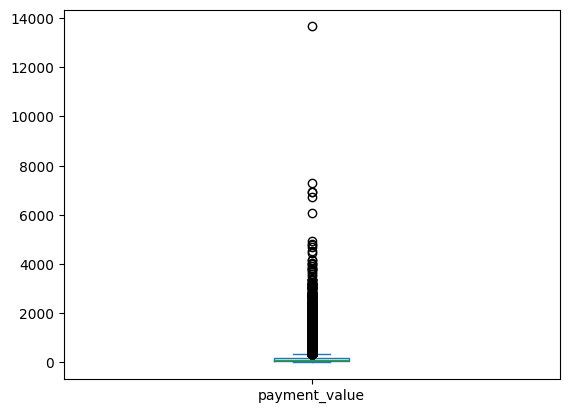

In [159]:
payments['payment_value'].plot(kind='box')

<Axes: xlabel='payment_installments', ylabel='payment_value'>

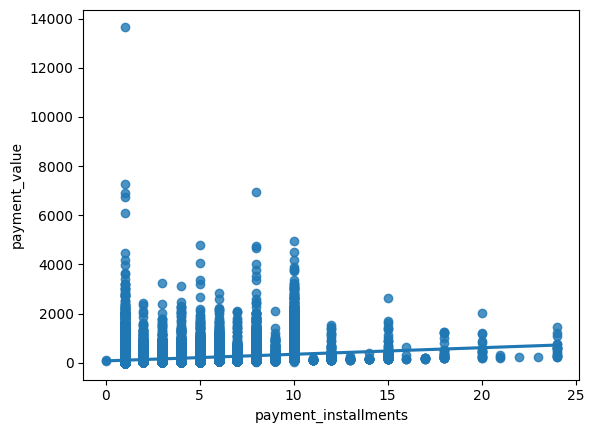

In [160]:
sns.regplot(x=payments['payment_installments'],y=payments['payment_value'])

## Seller

In [161]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [162]:
sellers['seller_city'].value_counts().reset_index().head(10)

,seller_city,count
0,sao paulo,694
1,curitiba,127
2,rio de janeiro,96
3,belo horizonte,68
4,ribeirao preto,52
5,guarulhos,50
6,ibitinga,49
7,santo andre,45
8,campinas,41
9,maringa,40


In [163]:
sellers['seller_state'].value_counts().reset_index().head(10)

,seller_state,count
0,SP,1849
1,PR,349
2,MG,244
3,SC,190
4,RJ,171
5,RS,129
6,GO,40
7,DF,30
8,ES,23
9,BA,19


In [164]:
sellers['seller_zip_code_prefix'].describe()

count     3095.000000
mean     32291.059451
std      32713.453830
min       1001.000000
25%       7093.500000
50%      14940.000000
75%      64552.500000
max      99730.000000
Name: seller_zip_code_prefix, dtype: float64

## category

In [165]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<Axes: xlabel='product_category_name'>

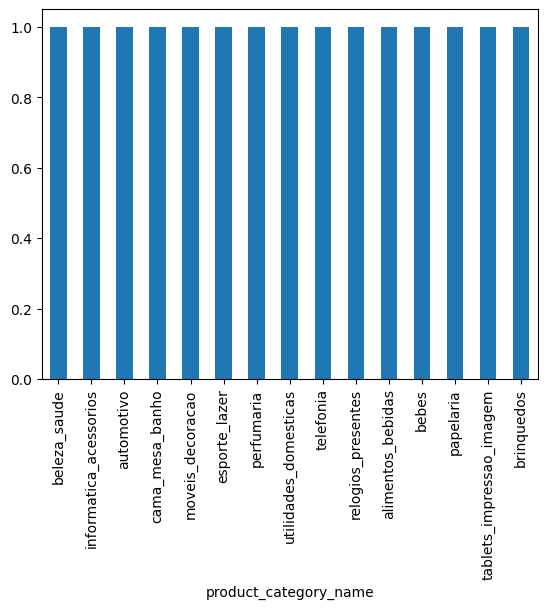

In [166]:
category['product_category_name'].head(15).value_counts().plot(kind='bar')

<Axes: xlabel='product_category_name_english'>

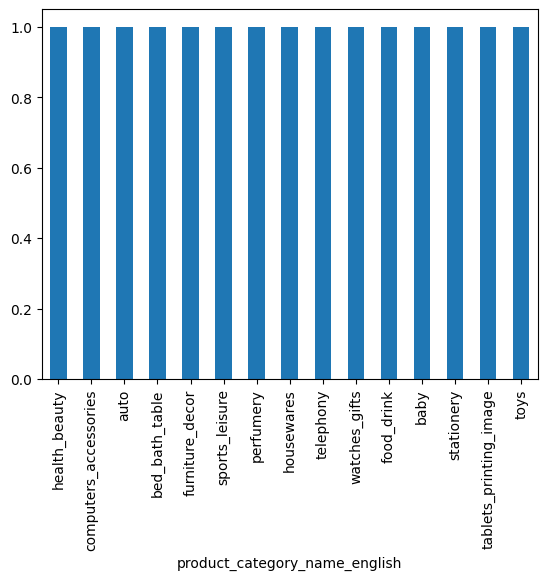

In [167]:
category['product_category_name_english'].head(15).value_counts().plot(kind='bar')

## geolocation

In [168]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1041,-23.544392,-46.639499,sao paulo,SP
3,1035,-23.541578,-46.641607,sao paulo,SP
4,1012,-23.547762,-46.635361,são paulo,SP


In [169]:
geolocation['geolocation_city'].value_counts().head(15).reset_index()

,geolocation_city,count
0,sao paulo,2652
1,são paulo,528
2,rio de janeiro,400
3,brasilia,393
4,salvador,275
5,belo horizonte,204
6,goiania,195
7,fortaleza,172
8,curitiba,167
9,porto alegre,142


<Axes: xlabel='geolocation_city'>

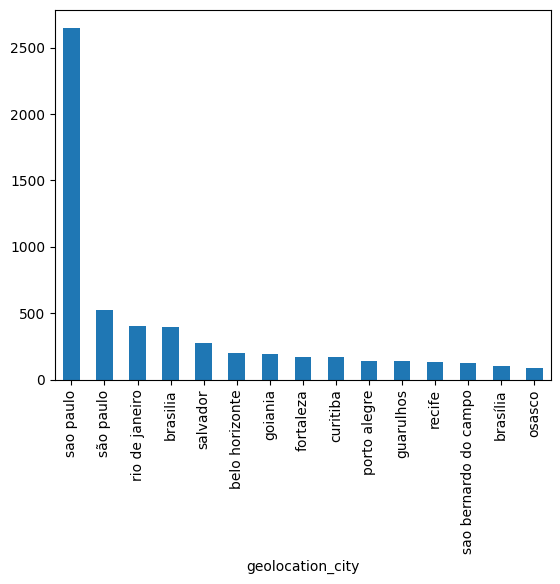

In [170]:
geolocation['geolocation_city'].value_counts().head(15).plot(kind='bar')

In [171]:
geolocation['geolocation_state'].value_counts().head(15).reset_index()

,geolocation_state,count
0,SP,6349
1,MG,1868
2,RJ,1390
3,RS,1131
4,PR,1046
5,BA,992
6,GO,773
7,SC,619
8,PE,596
9,CE,548


<Axes: xlabel='geolocation_state'>

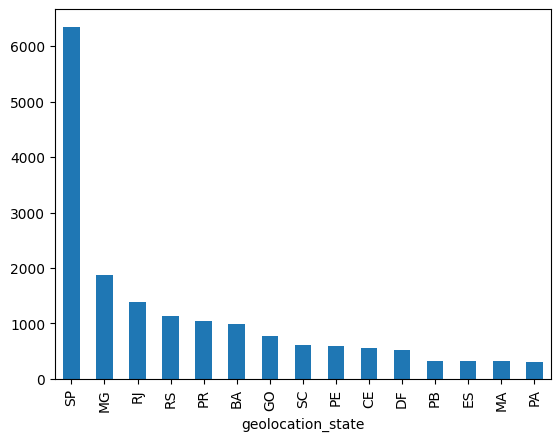

In [172]:
geolocation['geolocation_state'].value_counts().head(15).plot(kind='bar')

In [173]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1041,-23.544392,-46.639499,sao paulo,SP
3,1035,-23.541578,-46.641607,sao paulo,SP
4,1012,-23.547762,-46.635361,são paulo,SP


In [174]:
geolocation.groupby('geolocation_city')['geolocation_zip_code_prefix'].count().head(20)

geolocation_city
abadia de goias         1
abadia dos dourados     1
abadiania               1
abaete                  1
abaetetuba              1
abaiara                 1
abaira                  1
abare                   1
abatia                  1
abdon batista           1
abel figueiredo         1
abelardo luz            1
abrantes                1
abre campo              1
abreu e lima           12
abreulândia             1
abreus                  1
acaiaca                 1
acailandia              1
acajutiba               1
Name: geolocation_zip_code_prefix, dtype: int64

**Abreu e Lima, this city has 12 customer locations**

In [175]:
geolocation.groupby('geolocation_city')['geolocation_state'].nunique().head(20).sort_values(ascending=False)

geolocation_city
abadia de goias        1
abadia dos dourados    1
abadiania              1
abaete                 1
abaetetuba             1
abaiara                1
abaira                 1
abare                  1
abatia                 1
abdon batista          1
abel figueiredo        1
abelardo luz           1
abrantes               1
abre campo             1
abreu e lima           1
abreulândia            1
abreus                 1
acaiaca                1
acailandia             1
acajutiba              1
Name: geolocation_state, dtype: int64

# merge

In [176]:
df = orders.merge(customers, on='customer_id')\
           .merge(order_items, on='order_id')\
           .merge(products, on='product_id')\
           .merge(sellers, on='seller_id')\
           .merge(payments, on='order_id')\
           .merge(reviews, on='order_id', how='left')


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118299 entries, 0 to 118298
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118299 non-null  object        
 1   customer_id                    118299 non-null  object        
 2   order_status                   118299 non-null  object        
 3   order_purchase_timestamp       118299 non-null  datetime64[ns]
 4   order_approved_at              118299 non-null  datetime64[ns]
 5   order_delivered_carrier_date   118299 non-null  object        
 6   order_delivered_customer_date  118299 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118299 non-null  datetime64[ns]
 8   delivery_days                  118299 non-null  int64         
 9   delivery_delay                 118299 non-null  int64         
 10  purchase_month                 118299 non-null  int32         
 11  

In [178]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,...,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,Response_time_days,review_creation_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,1.0,10.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,1.0,10.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,<bound method NDFrame.fillna of 0 2017-1...,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,1.0,10.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,<bound method NDFrame.fillna of 0 2017-1...,2018-08-07 15:27:45,2018-08-13,13,-6,...,1,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,0.0,8.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,<bound method NDFrame.fillna of 0 2017-1...,2018-08-17 18:06:29,2018-09-04,9,-18,...,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58,4.0,8.0


In [179]:
# df.to_csv("DataFrame.csv",index=False)

In [180]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'delivery_delay', 'purchase_month', 'purchase_year',
       'purchase_Day', 'Transaction', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'revi

## Average actual delivery time

In [1]:
df['delivery_days'].describe()

NameError: name 'df' is not defined

**mean Actual Delivery Time = 12**

<Axes: >

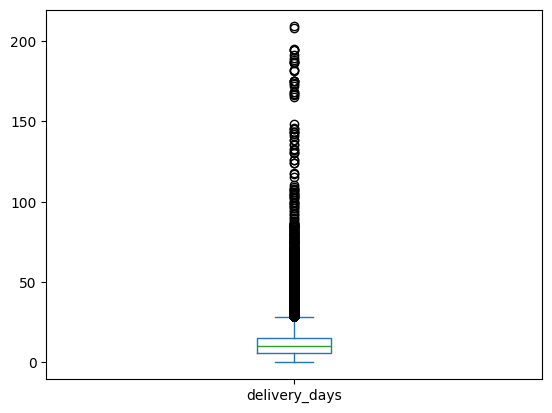

In [182]:
df['delivery_days'].plot(kind='box')

## Average delivery delay

In [183]:
df['delivery_delay'].describe()

count    118299.000000
mean        -12.073052
std          10.181160
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay, dtype: float64

**Mean delivery delay = -12**

<Axes: >

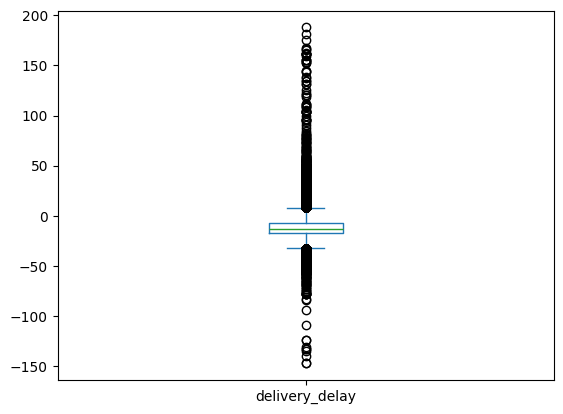

In [184]:
df['delivery_delay'].plot(kind='box')

## Percentage of late orders versus on-time orders

In [185]:
df['delivery_delay'].apply(lambda x: 'Late' if x>0 else 'On Time').value_counts(normalize=True).reset_index()

,delivery_delay,proportion
0,On Time,0.934716
1,Late,0.065284


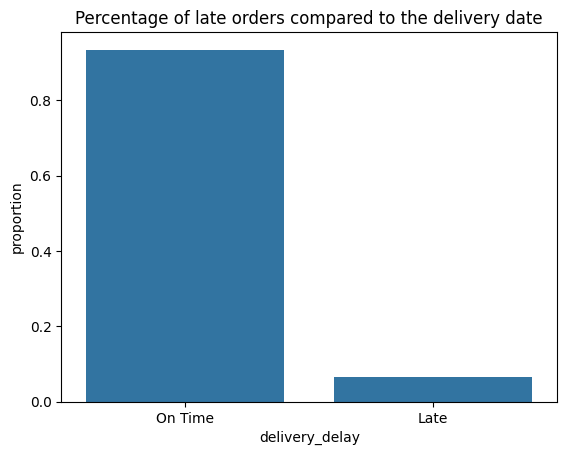

In [186]:
percentage_of_late=df['delivery_delay'].apply(lambda x: 'Late' if x>0 else 'On Time').value_counts(normalize=True).reset_index()
sns.barplot(percentage_of_late,x='delivery_delay',y='proportion')
plt.title("Percentage of late orders compared to the delivery date")
plt.show()

**Percentage of late orders compared to the delivery date = 6%**

## relationship between the delay and the evaluations

In [187]:
df.loc[:,['delivery_delay','review_score']].corr()

,delivery_delay,review_score
delivery_delay,1.000000,-0.212783
review_score,-0.212783,1.000000


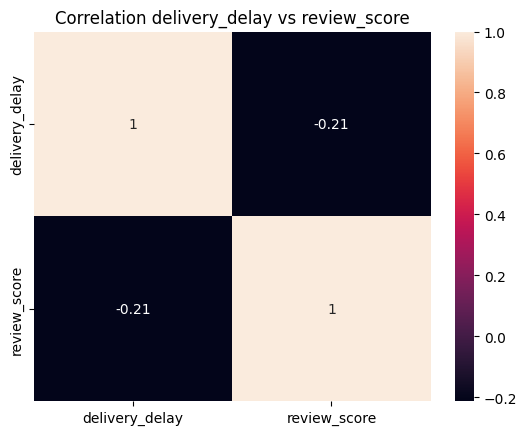

In [188]:
corr=df.loc[:,['delivery_delay','review_score']].corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation delivery_delay vs review_score")
plt.show()

**Delaying the application process does not affect the ratings.**

## Average rating based on delivery status (late/on time)

In [189]:
df.groupby(df['delivery_delay']>0)['review_score'].mean().reset_index()

,delivery_delay,review_score
0,False,4.153952
1,True,2.244320


<Axes: ylabel='Density'>

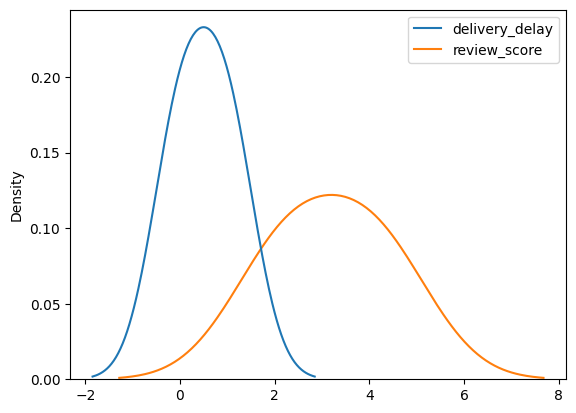

In [190]:
sns.kdeplot(df.groupby(df['delivery_delay']>0)['review_score'].mean().reset_index())

**the KDE plot shows that delivery delays cluster around zero, while review scores are mostly high.
Because the two distributions do not overlap and operate on different scales, the linear correlation appears weak.
This indicates that customer ratings are noisy and not directly driven by delivery delay**

In [191]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'delivery_delay', 'purchase_month', 'purchase_year',
       'purchase_Day', 'Transaction', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'revi

## Highest number of orders per month

In [192]:
df['purchase_month'].value_counts().sort_index().reset_index()

,purchase_month,count
0,1,9626
1,2,10095
2,3,11793
3,4,11136
4,5,12675
5,6,11215
6,7,12240
7,8,12688
8,9,5140
9,10,6002


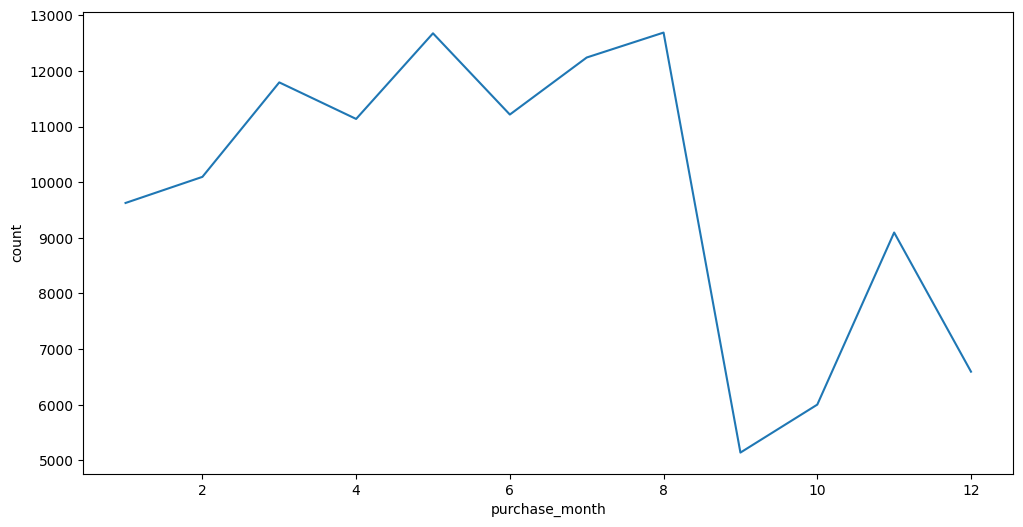

In [193]:
plt.figure(figsize=(12,6))
sns.lineplot(df['purchase_month'].value_counts(),markers='point')
plt.show()

**Orders increase steadily from January to August, the peak sales season.
Then there's a sharp dip in September, followed by a partial recovery in November due to Black Friday, but December doesn't return to peak levels.**

## Highest quality ratings

In [194]:
df.groupby('purchase_month')['review_score'].mean()

purchase_month
1     3.961611
2     3.808238
3     3.799179
4     4.052069
5     4.133185
6     4.170016
7     4.183532
8     4.220291
9     4.138627
10    4.034158
11    3.842450
12    3.950935
Name: review_score, dtype: float64

In [195]:
df.loc[: ,['review_score','purchase_month']].corr()

,review_score,purchase_month
review_score,1.000000,0.029114
purchase_month,0.029114,1.000000


**The highest-rated month is August, which is normal because it has the highest sales volume. There is a correlation between months with high sales volume and customer reviews, but the correlation is not strong.**

## Average payment per order

In [196]:
df.groupby('order_id')['payment_value'].sum().mean()

np.float64(206.93375655047285)

In [197]:
df.groupby('order_id')['payment_value'].sum().sample(10)

order_id
8f5a539f581d3e8bbd7ceda637dca43e     35.77
6bd24c02ac923942e7428dde3797ecd4     43.93
39bcd5ec1743f20b61498be2277d28db    143.38
451ef728c85c9cb2765159e30f4fa021     86.86
d2e98c2b35f0e9173b4fce9cf61530d3    335.47
943980abcbc522eb49346398ee2594b4     37.79
aee3d95a7c0524bee2967e283ca5fb13    181.51
23d00a56e9a6088d2263041613defe1a    116.94
945cebd7f0d6886e7971663839507ec4     49.75
db7278dea8450817ee8e59fd074eedcd    130.77
Name: payment_value, dtype: float64

**Average total payment per order = 206.93**

## Orders are with high installment plans more valuable

In [198]:
df.loc[:,['payment_value','payment_installments']].corr()

,payment_value,payment_installments
payment_value,1.000000,0.273684
payment_installments,0.273684,1.000000


In [199]:
df.groupby('payment_installments')['payment_value'].mean().sort_index().reset_index()

,payment_installments,payment_value
0,0,106.190000
1,1,132.278868
2,2,134.506921
3,3,154.191059
4,4,178.747408
5,5,197.603031
6,6,233.678745
7,7,193.245857
8,8,309.504367
9,9,203.567041


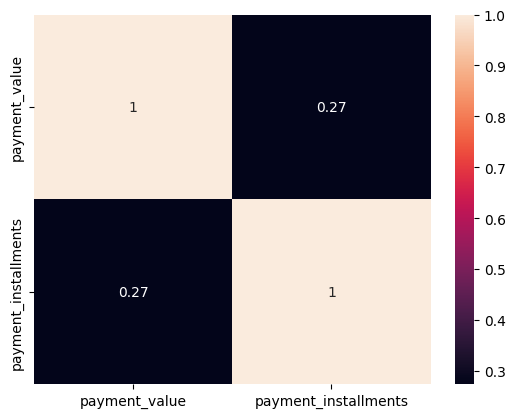

In [200]:
corr = df.loc[:,['payment_value','payment_installments']].corr()
sns.heatmap(corr,annot=True)
plt.show()

**There is a relationship between orders with high installment plans and the order value itself; the higher the order value, the more installments are made.**

## Highest Buying Customers (Best Customers)

In [201]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'delivery_delay', 'purchase_month', 'purchase_year',
       'purchase_Day', 'Transaction', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'revi

In [202]:
df['customer_id'].value_counts().head(10)

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
d22f25a9fadfb1abbc2e29395b1239f4    24
86cc80fef09f7f39df4b0dbce48e81cb    24
63b964e79dee32a3587651701a2b8dbf    24
6ee2f17e3b6c33d6a9557f280edd2925    24
2ba91e12e5e4c9f56b82b86d9031d329    24
b246eeed30b362c09d867b9e598bee51    22
Name: count, dtype: int64

## Average storage response time for reviews

In [203]:
df['Response_time_days'].mean()

np.float64(2.579018249077318)

In [204]:
df[['Response_time_days','review_score']].corr()


,Response_time_days,review_score
Response_time_days,1.000000,0.009456
review_score,0.009456,1.000000


## Percentage of cases according to order_status

In [205]:
df['order_status'].value_counts(normalize=True)*100

order_status
delivered      97.813168
shipped         1.060871
canceled        0.481830
invoiced        0.317839
processing      0.317839
unavailable     0.005917
approved        0.002536
Name: proportion, dtype: float64

In [206]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'delivery_delay', 'purchase_month', 'purchase_year',
       'purchase_Day', 'Transaction', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'revi

## Which states complain the most?

In [207]:
df.groupby(geolocation['geolocation_state'])['delivery_delay'].sum()

geolocation_state
AC     -524
AL    -2069
AM    -1841
AP     -355
BA   -11378
CE    -6347
DF    -6354
ES    -3751
GO    -9017
MA    -3394
MG   -22232
MS    -3034
MT    -3092
PA    -3322
PB    -3569
PE    -7214
PI    -3635
PR   -12509
RJ   -17338
RN    -3256
RO    -1177
RR     -287
RS   -13816
SC    -7375
SE    -1664
SP   -77151
TO    -2103
Name: delivery_delay, dtype: int64

## who the seller cause more delays?

In [208]:
df.groupby('seller_id')['delivery_delay'].mean().sort_values(ascending=False).reset_index()

,seller_id,delivery_delay
0,df683dfda87bf71ac3fc63063fba369d,167.0
1,8e670472e453ba34a379331513d6aab1,35.0
2,4fb41dff7c50136976d1a5cf004a42e2,33.0
3,8629a7efec1aab257e58cda559f03ba7,33.0
4,be1e9e378700cecaa4ebf71433d7915c,23.5
...,...,...
3090,fa5fdc4e4bb6bd1009ad0e4ac4096562,-58.0
3091,0b09101900100c0e9d312861fad5a1b9,-61.0
3092,7e959205cebc10adefcb331f934238a4,-63.0
3093,7a073a40a9d3f1fee8bc45670ea1e909,-68.0
